# Q1

###  **1.1 Assumptions**

(a) Likelihood: $x \sim B(n=10, \theta)$. For $y=7$:

$$\mathcal{L}(\theta|y) = \frac{10!}{7!(10-7)!} \theta^7 (1-\theta)^3 = 120 \theta^7 (1-\theta)^3$$

(b) Prior: $p(\theta) = 2$ for $0.5 \le \theta \le 1$, else $0$.

### **1.2 Statistical inference**

Marginal likelihood given: $P(y) = \int \mathcal{L}(\theta|y)p(\theta) d\theta = \frac{227}{1056}$

Posterior density: $p(\theta|y) = \frac{\mathcal{L}(\theta|y)p(\theta)}{P(y)}$


In [11]:

m_lik <- 227/1056
lik_fn <- function(t) ifelse(t >= 0 & t <= 1, choose(10, 7) * t^7 * (1-t)^3, 0)
prior_fn <- function(t) ifelse(t >= 0.5 & t <= 1, 2, 0)
post_fn <- function(t) (lik_fn(t) * prior_fn(t)) / m_lik


### **1.4 Exercises**
## 1. Estimate posterior density:
*  $\theta = 0.75$:



In [6]:
post_fn(0.75)

[1] 2.328618



*  $\theta = 0.25$:



In [7]:
post_fn(0.25)

[1] 0



*  $\theta = 1$:




In [8]:
post_fn(1)

[1] 0

### **Posterior distribution:**

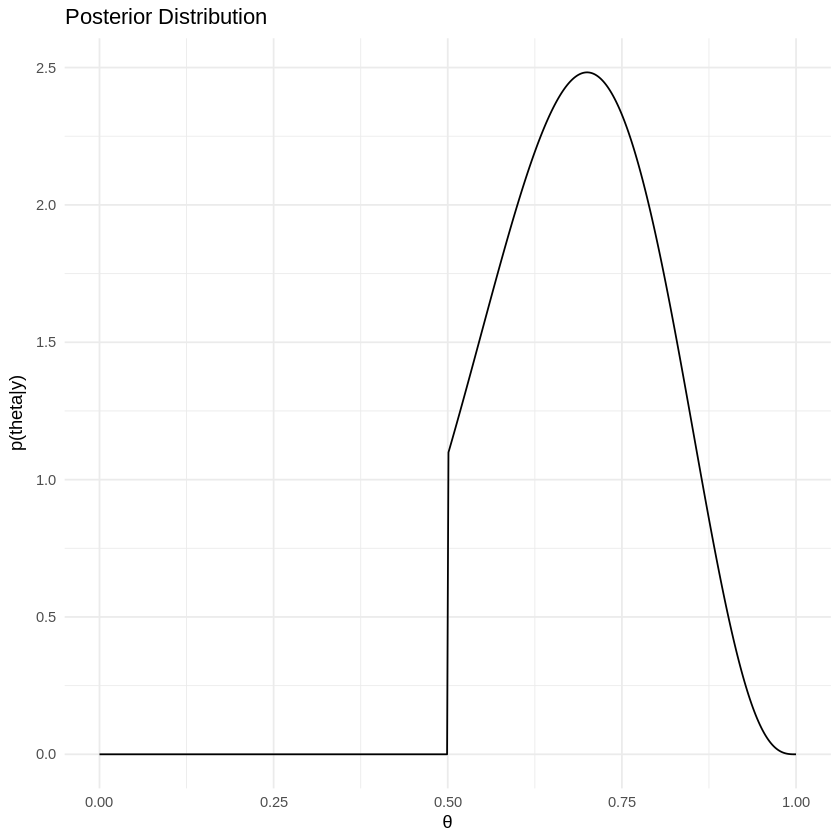

In [19]:
library(ggplot2)

theta_v <- seq(0, 1, length.out = 500)
df <- data.frame(theta = theta_v, post = sapply(theta_v, post_fn))

ggplot(df, aes(theta, post)) +
  geom_line() +
  labs(title="Posterior Distribution", x=expression(theta), y="p(theta|y)") +
  theme_minimal()


 3. Value of $\theta$ with maximum posterior density:
The prior is constant on $[0.5, 1]$.
Mode of likelihood is $y/n = 7/10 = 0.7$.
Since $0.7 \in [0.5, 1]$, $\theta$max = 0.7.

4. Compare Likelihood, Prior, and Posterior:

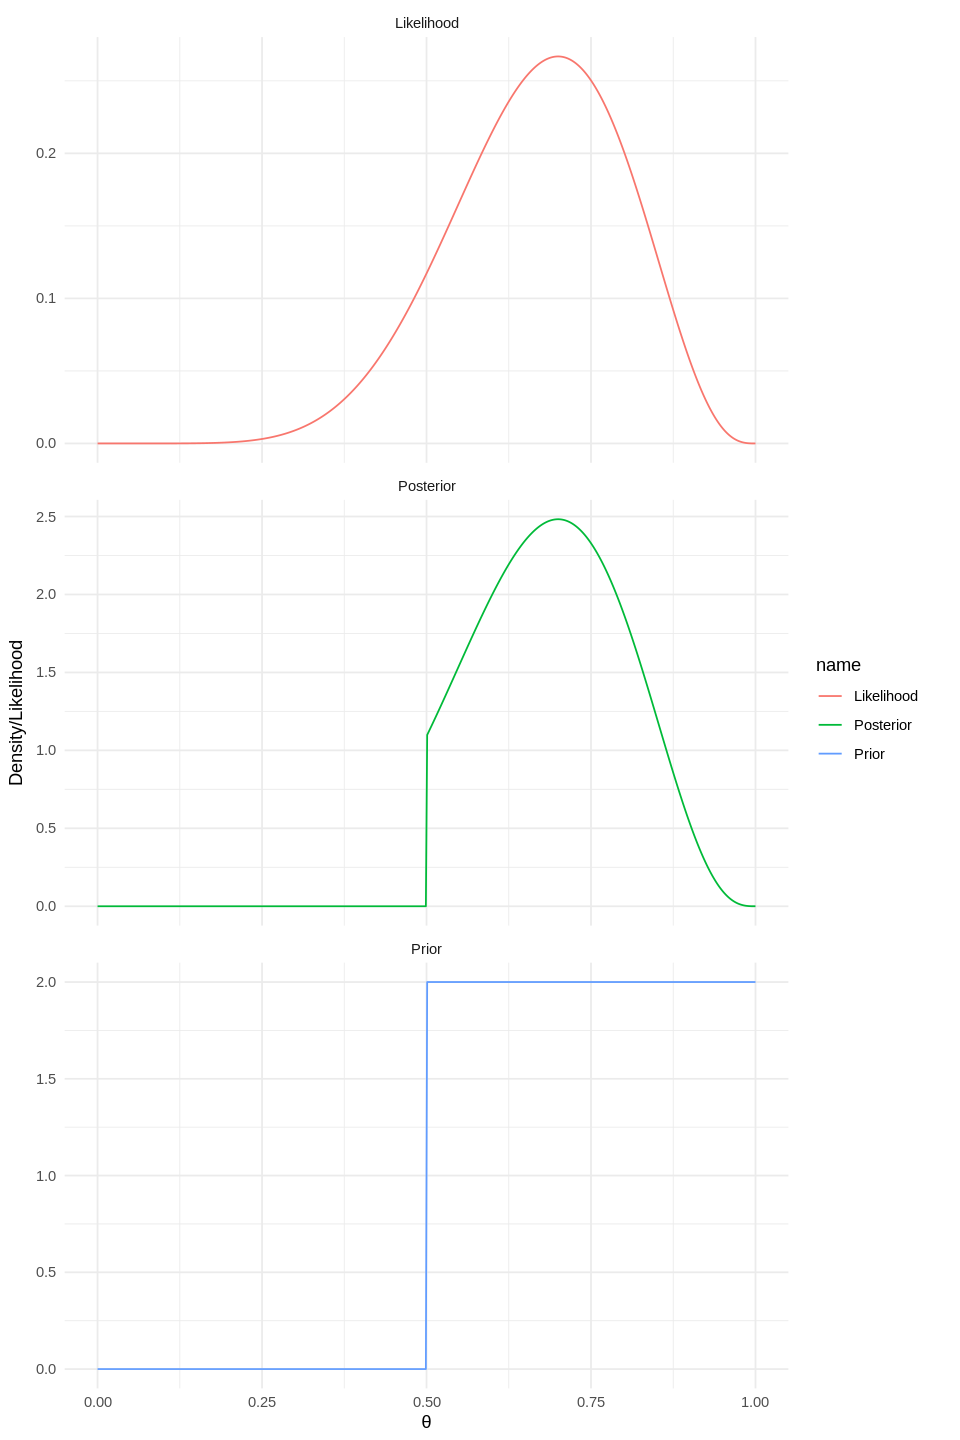

In [27]:
df_comp <- data.frame(
  theta = theta_v,
  Likelihood = sapply(theta_v, lik_fn),
  Prior = sapply(theta_v, prior_fn),
  Posterior = sapply(theta_v, post_fn)
)

library(tidyr)
df_long <- pivot_longer(df_comp, -theta)
options(repr.plot.width = 8, repr.plot.height = 12)

ggplot(df_long, aes(theta, value, color=name)) +
  geom_line() +
  facet_wrap(~name, scales="free_y", ncol=1) +
  theme_minimal() +
  labs(y="Density/Likelihood", x=expression(theta))



#Q 2.

In [33]:

library(truncnorm)
 dat <- read.csv("recognition.csv", header = TRUE)
 Tw <- dat$Tw
Tnw <- dat$Tnw

###2.5
**Question 1: Graph of unnormalized posterior distribution of $\mu$ .**

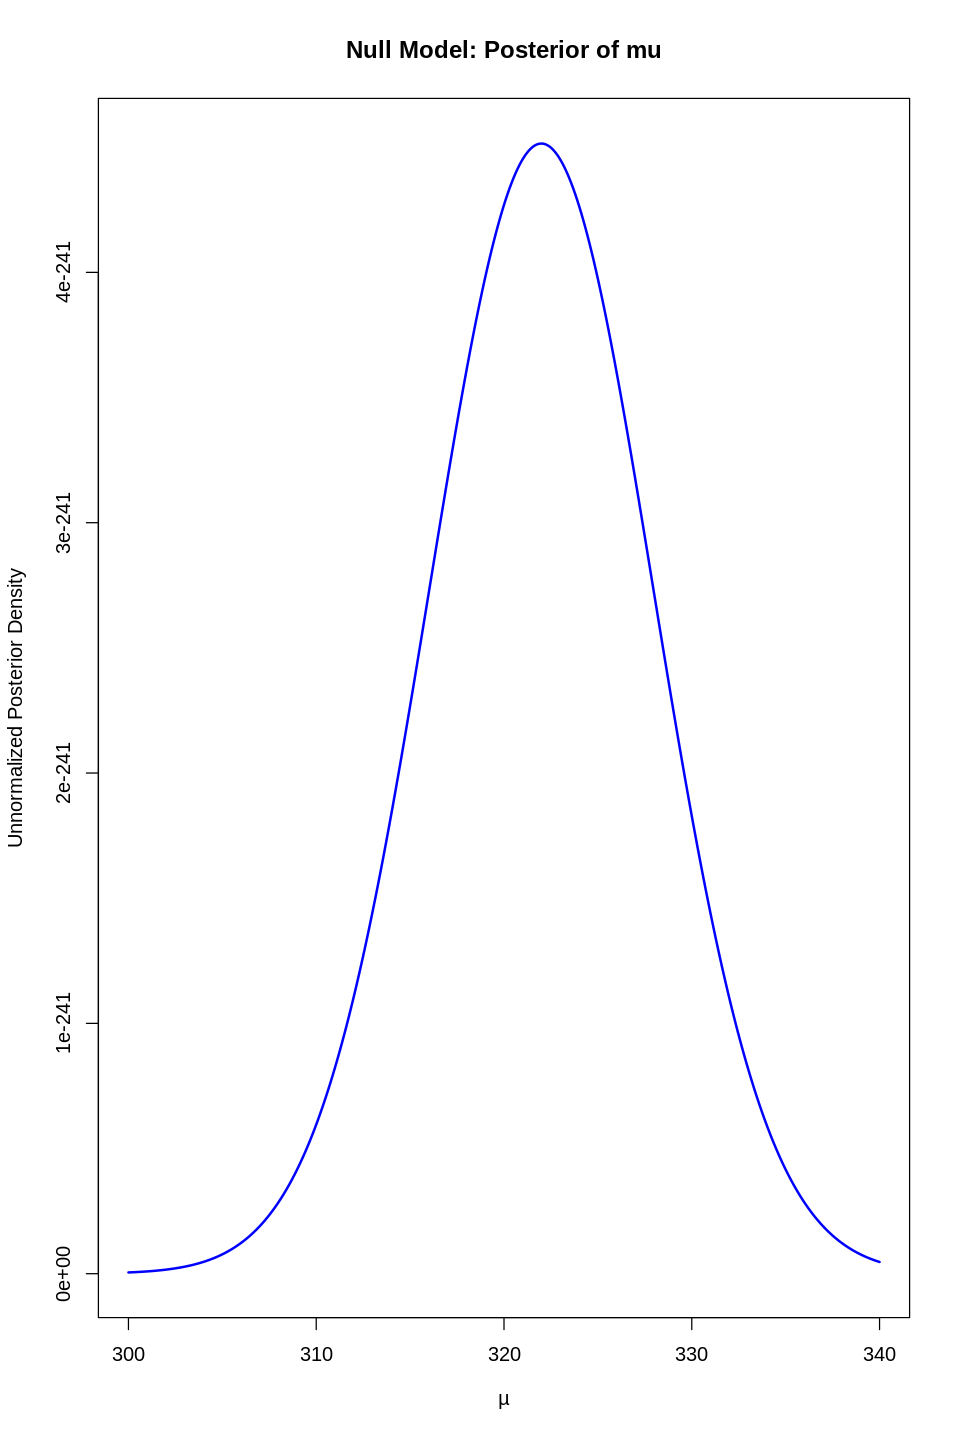

In [34]:
unnorm_post_mu_null <- function(mu_val) {
  lik_w <- prod(dnorm(Tw, mean = mu_val, sd = 60))
  lik_nw <- prod(dnorm(Tnw, mean = mu_val, sd = 60))
  prior_mu <- dnorm(mu_val, mean = 300, sd = 50)
  return(lik_w * lik_nw * prior_mu)
}

mu_seq <- seq(300, 340, length.out = 500)
post_mu_null_vals <- sapply(mu_seq, unnorm_post_mu_null)

plot(mu_seq, post_mu_null_vals, type = 'l', col = 'blue', lwd = 2,
     xlab = expression(mu), ylab = 'Unnormalized Posterior Density',
     main = 'Null Model: Posterior of mu')




**Question 2: Prior predictions from the lexical-access model.**

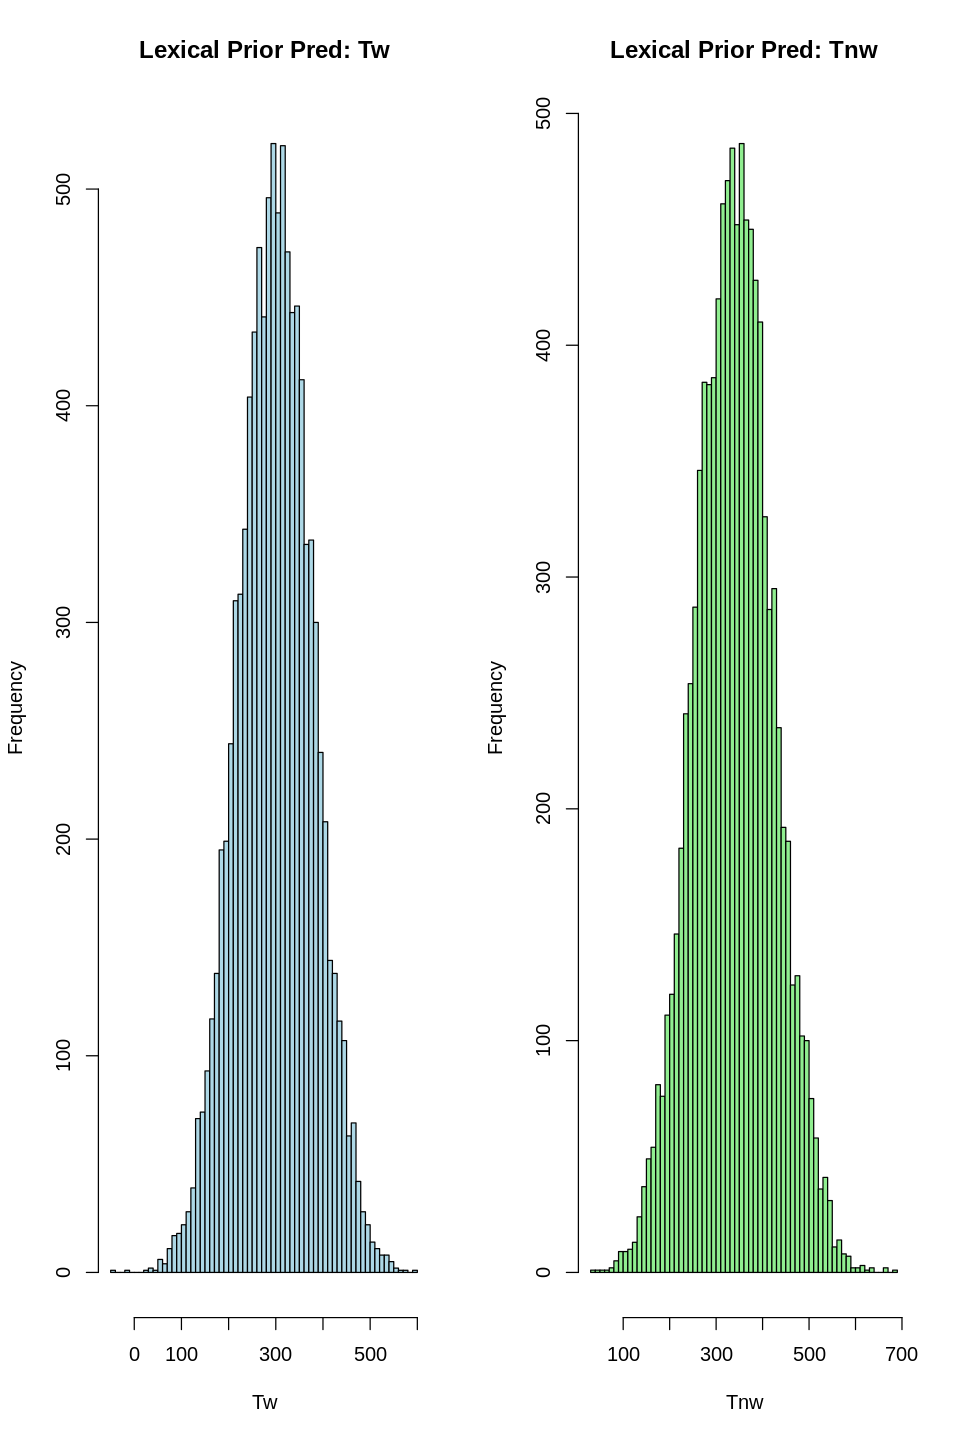

In [36]:
set.seed(42)
n_sim <- 10000
mu_prior <- rnorm(n_sim, mean = 300, sd = 50)
delta_prior <- rtruncnorm(n_sim, a = 0, b = Inf, mean = 0, sd = 50)
Tw_pred_lex <- rnorm(n_sim, mean = mu_prior, sd = 60)
Tnw_pred_lex <- rnorm(n_sim, mean = mu_prior + delta_prior, sd = 60)
par(mfrow = c(1, 2))
hist(Tw_pred_lex, breaks = 50, col = 'lightblue', main = 'Lexical Prior Pred: Tw', xlab = 'Tw')
hist(Tnw_pred_lex, breaks = 50, col = 'lightgreen', main = 'Lexical Prior Pred: Tnw', xlab = 'Tnw')

**Question 3: Compare the prior predictions of the null hypothesis model and the lexical access model.**

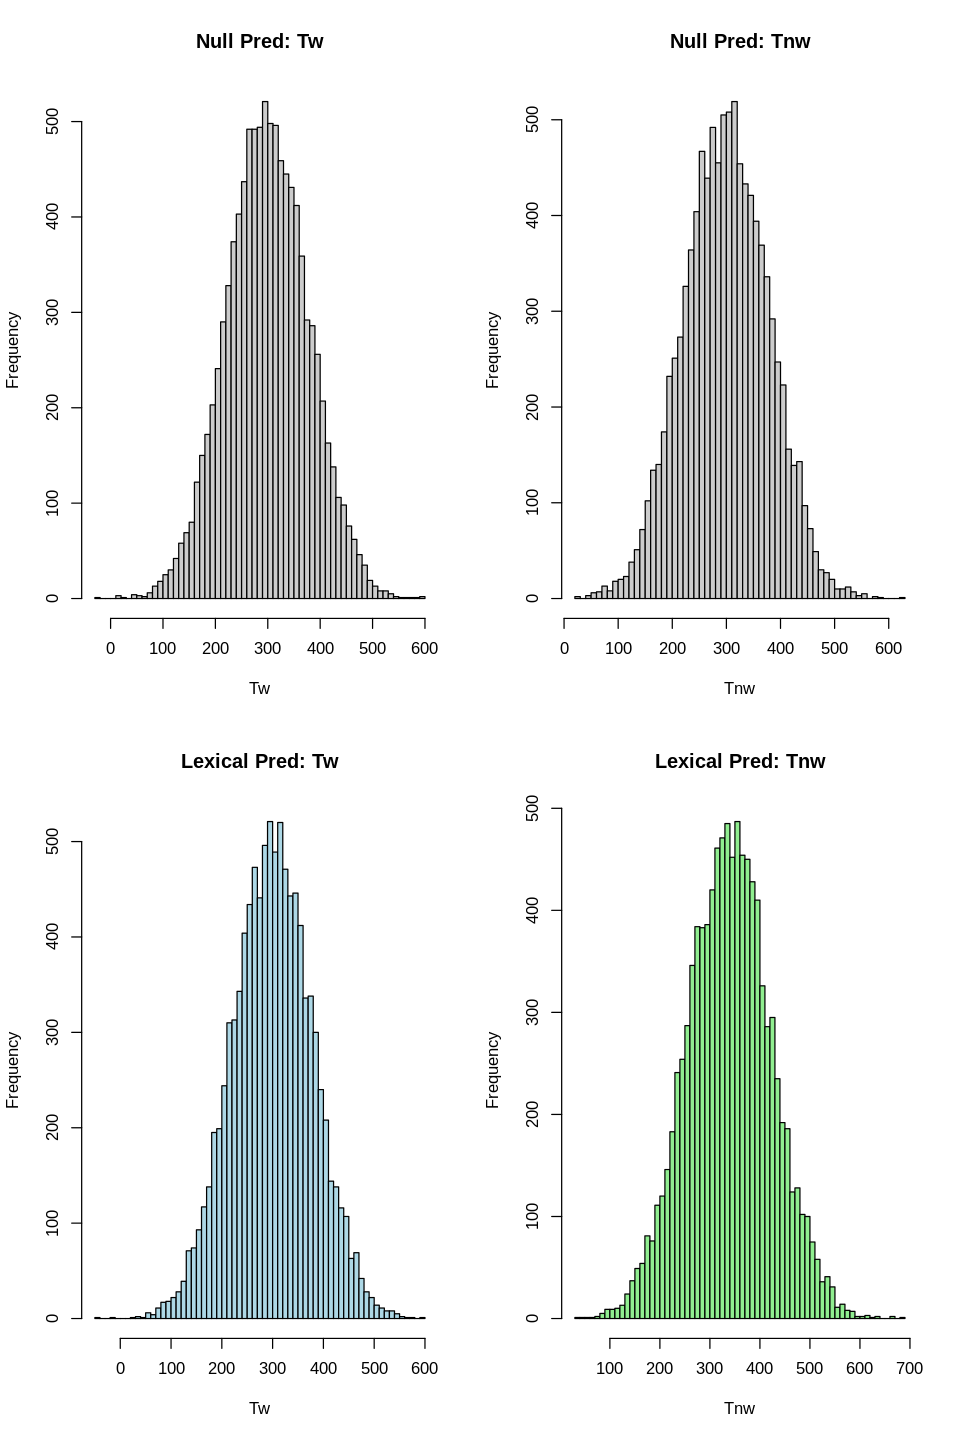

In [37]:

Tw_pred_null <- rnorm(n_sim, mean = mu_prior, sd = 60)
Tnw_pred_null <- rnorm(n_sim, mean = mu_prior, sd = 60)
par(mfrow = c(2, 2))
hist(Tw_pred_null, breaks = 50, col = 'grey80', main = 'Null Pred: Tw', xlab = 'Tw')
hist(Tnw_pred_null, breaks = 50, col = 'grey80', main = 'Null Pred: Tnw', xlab = 'Tnw')
hist(Tw_pred_lex, breaks = 50, col = 'lightblue', main = 'Lexical Pred: Tw', xlab = 'Tw')
hist(Tnw_pred_lex, breaks = 50, col = 'lightgreen', main = 'Lexical Pred: Tnw', xlab = 'Tnw')

**Question 4: Compare the prior predictions of each model against the observed data $T_w$ and $T_{nw}$. Which model seems more consistent with the data?**

**Conclusion:** The lexical model allows a small slight systematic shift between Tw and Tnw, which matches the observed pattern; the null model cannot.

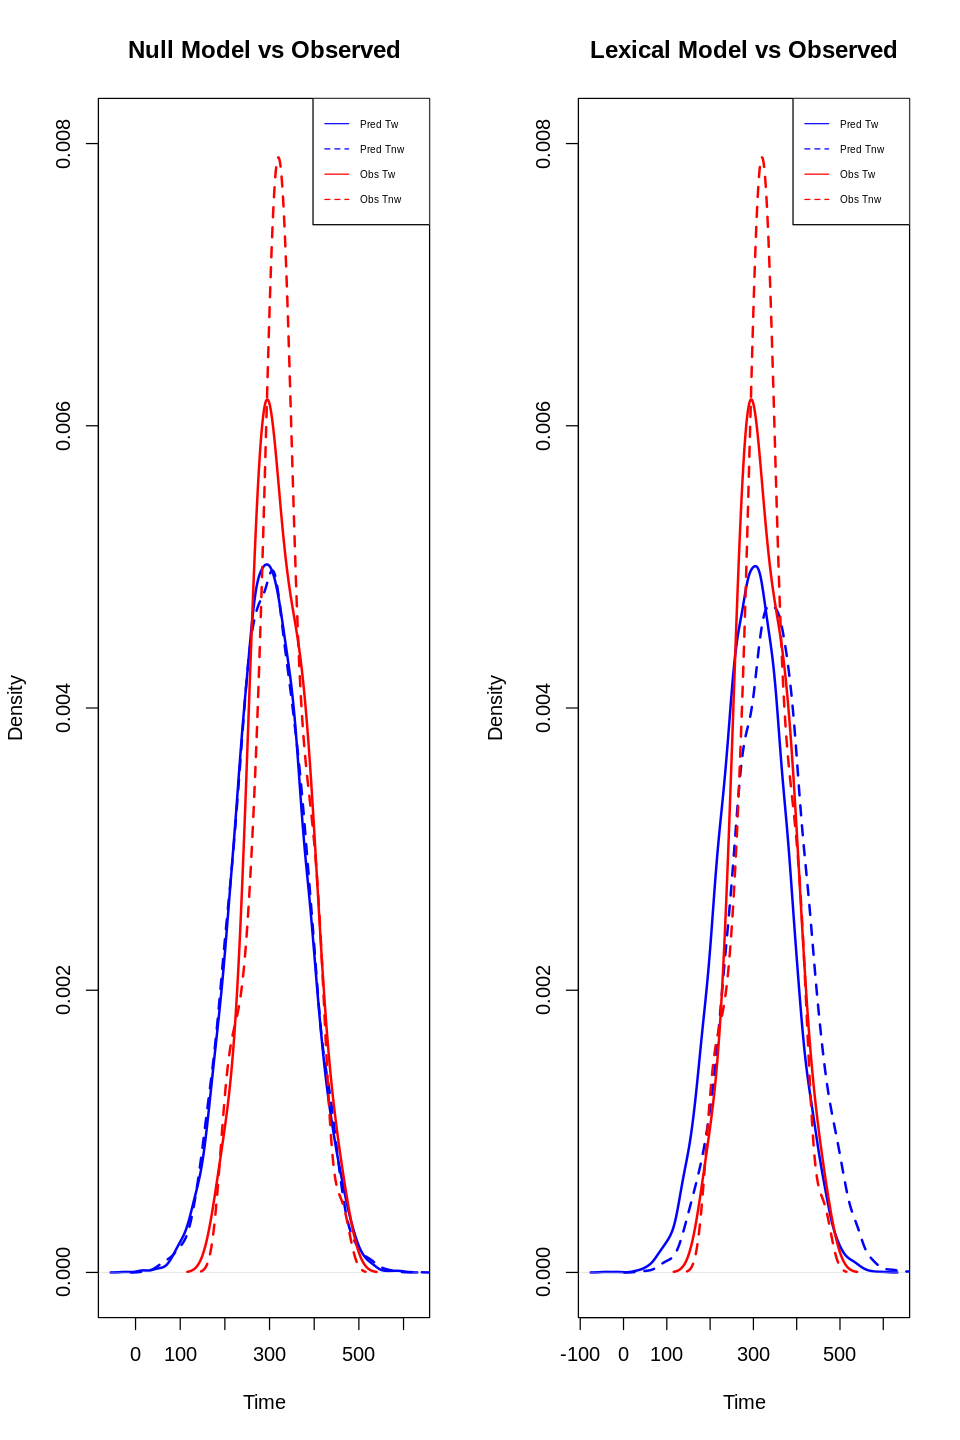

In [41]:
par(mfrow = c(1, 2))

# Null Model vs Observed Data
plot(density(Tw_pred_null), col = "blue", lwd = 2, main = "Null Model vs Observed", xlab = "Time", ylim = c(0, 0.008))
lines(density(Tnw_pred_null), col = "blue", lwd = 2, lty = 2)
lines(density(Tw), col = "red", lwd = 2)
lines(density(Tnw), col = "red", lwd = 2, lty = 2)
legend("topright", legend = c("Pred Tw", "Pred Tnw", "Obs Tw", "Obs Tnw"),
       col = c("blue", "blue", "red", "red"), lty = c(1, 2, 1, 2), cex = 0.5)

# Lexical Model vs Observed Data
plot(density(Tw_pred_lex), col = "blue", lwd = 2, main = "Lexical Model vs Observed", xlab = "Time", ylim = c(0, 0.008))
lines(density(Tnw_pred_lex), col = "blue", lwd = 2, lty = 2)
lines(density(Tw), col = "red", lwd = 2)
lines(density(Tnw), col = "red", lwd = 2, lty = 2)
legend("topright", legend = c("Pred Tw", "Pred Tnw", "Obs Tw", "Obs Tnw"),
       col = c("blue", "blue", "red", "red"), lty = c(1, 2, 1, 2), cex = 0.5)


**Question 5: integrating (sum) the joint posterior over a grid of possible $\mu$ values.**

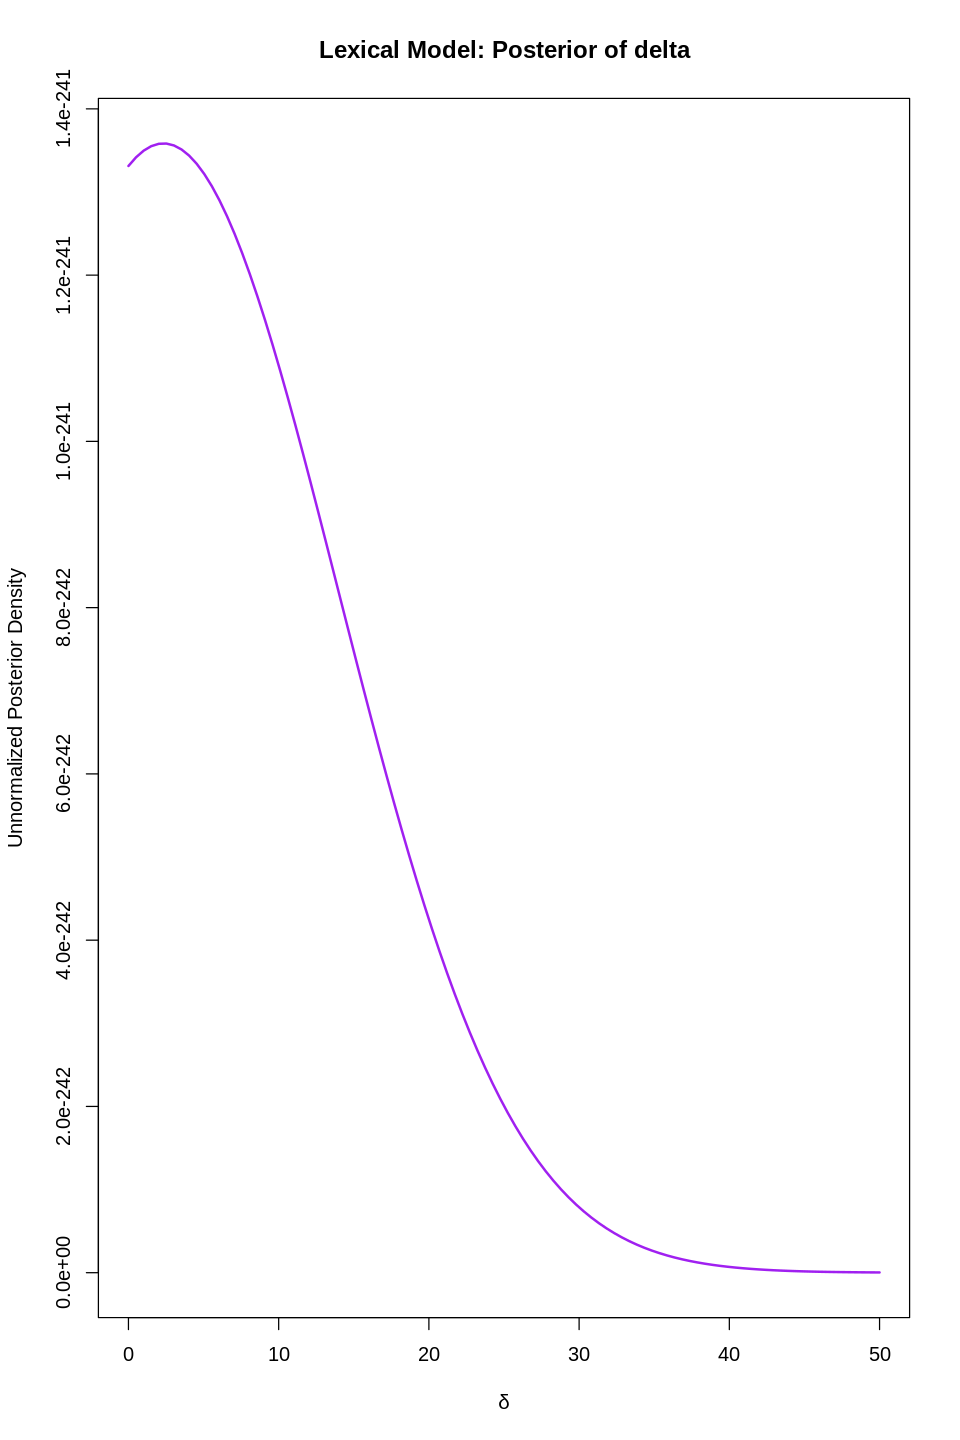

In [42]:
unnorm_post_delta <- function(delta_val) {
  mu_grid <- seq(280, 360, length.out = 100) # Grid of mu values
  sum_marginal <- 0

  for(m in mu_grid) {
    lik_w <- prod(dnorm(Tw, mean = m, sd = 60))
    lik_nw <- prod(dnorm(Tnw, mean = m + delta_val, sd = 60))
    prior_m <- dnorm(m, mean = 300, sd = 50)

    # Integrate over mu
    sum_marginal <- sum_marginal + (lik_w * lik_nw * prior_m)
  }

  prior_d <- dtruncnorm(delta_val, a = 0, b = Inf, mean = 0, sd = 50)
  return(sum_marginal * prior_d)
}

delta_seq <- seq(0, 50, length.out = 100)
post_delta_vals <- sapply(delta_seq, unnorm_post_delta)

plot(delta_seq, post_delta_vals, type = 'l', col = 'purple', lwd = 2,
     xlab = expression(delta), ylab = 'Unnormalized Posterior Density',
     main = 'Lexical Model: Posterior of delta')